# YOLO training - merged dataset (CAR, GCS, REF, SS, WB)


In [1]:
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.3 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import torch
print(torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'no gpu')

True Tesla T4


In [4]:
DATA_DIR = '/content/drive/MyDrive/T2_AFL/data_merged'
WORK_DIR = '/content/dataset'
VAL_SPLIT = 0.2
SEED = 42

MODEL = 'yolo11n.pt'
EPOCHS = 100
IMG_SIZE = 640
BATCH = 16

## Train/val split


In [5]:
import os, random, shutil

random.seed(SEED)
images = sorted(os.listdir(f'{DATA_DIR}/images'))
random.shuffle(images)
n_val = int(len(images) * VAL_SPLIT)
val_set = set(images[:n_val])

for split in ['train', 'val']:
    os.makedirs(f'{WORK_DIR}/{split}/images', exist_ok=True)
    os.makedirs(f'{WORK_DIR}/{split}/labels', exist_ok=True)

for img in images:
    split = 'val' if img in val_set else 'train'
    stem = os.path.splitext(img)[0]
    shutil.copy(f'{DATA_DIR}/images/{img}', f'{WORK_DIR}/{split}/images/{img}')
    label = f'{DATA_DIR}/labels/{stem}.txt'
    if os.path.exists(label):
        shutil.copy(label, f'{WORK_DIR}/{split}/labels/{stem}.txt')

print(f'train: {len(images) - n_val}, val: {n_val}')

train: 316, val: 78


In [6]:
with open(f'{DATA_DIR}/classes.txt') as f:
    class_names = [line.strip() for line in f if line.strip()]

yaml_lines = [f'path: {WORK_DIR}', 'train: train/images', 'val: val/images', '', 'names:']
yaml_lines += [f'  {i}: {name}' for i, name in enumerate(class_names)]

with open('/content/data.yaml', 'w') as f:
    f.write('\n'.join(yaml_lines))

print('\n'.join(yaml_lines))

path: /content/dataset
train: train/images
val: val/images

names:
  0: CAR
  1: GCS
  2: REF
  3: SS
  4: WB


## Train

In [7]:
from ultralytics import YOLO

model = YOLO(MODEL)
results = model.train(data='/content/data.yaml', epochs=EPOCHS, imgsz=IMG_SIZE, batch=BATCH, seed=SEED)

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.116 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torc

## Validation metrics

In [8]:
metrics = model.val()

print(f'mAP50: {metrics.box.map50:.4f}')
print(f'mAP50-95: {metrics.box.map:.4f}')
print(f'precision: {metrics.box.mp:.4f}')
print(f'recall: {metrics.box.mr:.4f}')

Ultralytics 8.4.116 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,583,127 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2673.4±755.1 MB/s, size: 177.2 KB)
val: Scanning /content/dataset/val/labels.cache... 78 images, 4 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 78/78 20.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.7it/s 3.0s
                   all         78        838      0.848      0.823       0.82       0.34
                   CAR         42        251      0.904      0.928      0.934      0.433
                   GCS         47        243      0.937      0.934      0.962      0.448
                   REF         54         98      0.891      0.748      0.818      0.368
                    SS         25        123      0.779      0.724      0.665       0.24
                    WB         26        123      0

In [9]:
for i, name in enumerate(class_names):
    p, r, ap50, ap = metrics.box.class_result(i)
    print(f'{name:5s} P={p:.3f} R={r:.3f} mAP50={ap50:.3f} mAP50-95={ap:.3f}')

CAR   P=0.904 R=0.928 mAP50=0.934 mAP50-95=0.433
GCS   P=0.937 R=0.934 mAP50=0.962 mAP50-95=0.448
REF   P=0.891 R=0.748 mAP50=0.818 mAP50-95=0.368
SS    P=0.779 R=0.724 mAP50=0.665 mAP50-95=0.240
WB    P=0.728 R=0.780 mAP50=0.723 mAP50-95=0.210


## Plots (confusion matrix, PR curve, loss/mAP curves)

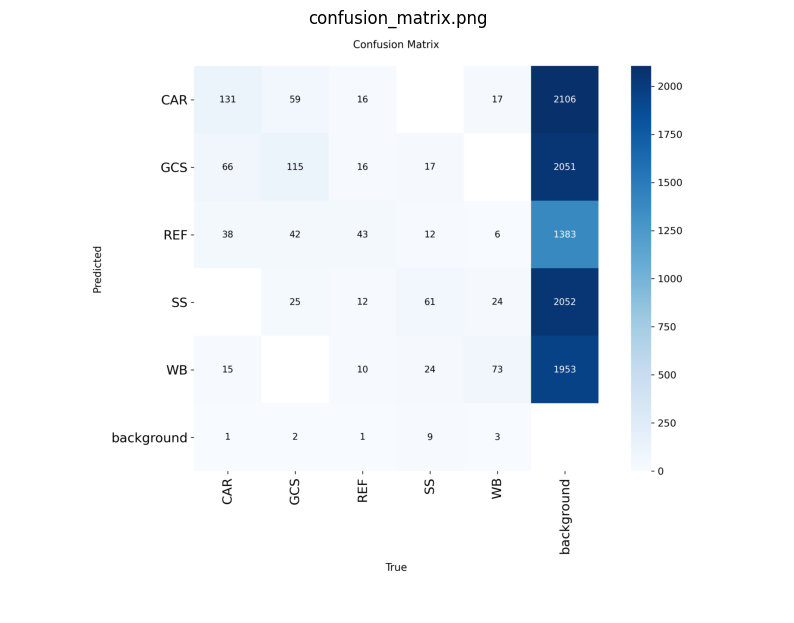

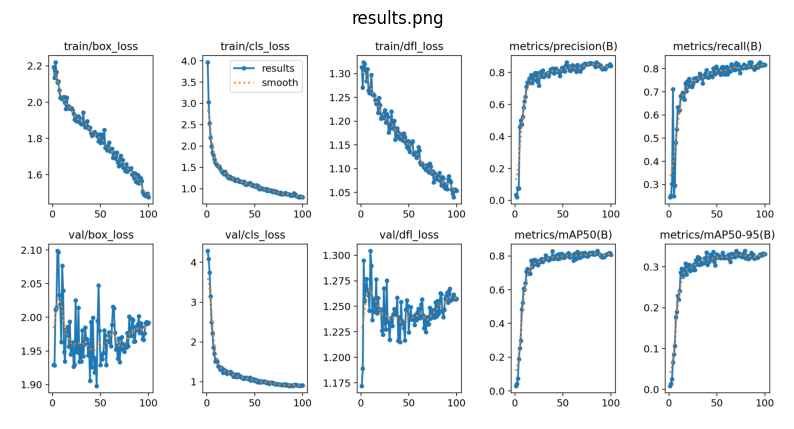

In [10]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

save_dir = model.trainer.save_dir
for name in ['confusion_matrix.png', 'PR_curve.png', 'results.png']:
    path = f'{save_dir}/{name}'
    if os.path.exists(path):
        plt.figure(figsize=(10, 8))
        plt.imshow(mpimg.imread(path))
        plt.axis('off')
        plt.title(name)
        plt.show()

## Sample predictions on val set


0: 640x640 1 GCS, 5.1ms
1: 640x640 2 REFs, 12 SSs, 9 WBs, 5.1ms
2: 640x640 6 CARs, 6 GCSs, 1 REF, 5.1ms
3: 640x640 6 CARs, 9 GCSs, 5.1ms
4: 640x640 1 GCS, 5.1ms
5: 640x640 13 CARs, 9 GCSs, 2 REFs, 5.1ms
Speed: 2.4ms preprocess, 5.1ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)


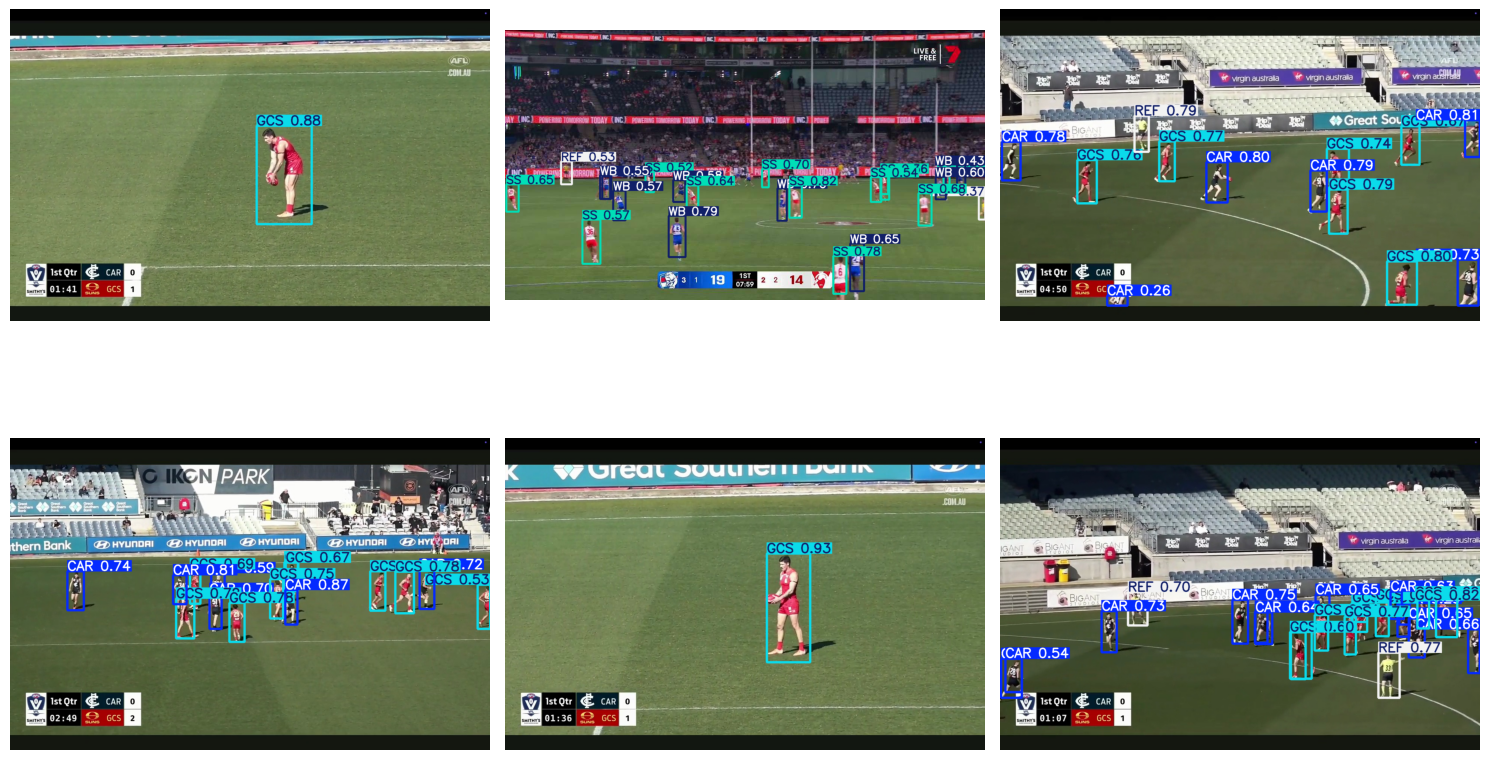

In [11]:
import glob

sample_imgs = glob.glob(f'{WORK_DIR}/val/images/*.jpg')[:6]
preds = model.predict(sample_imgs, conf=0.25)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, r in zip(axes.flatten(), preds):
    ax.imshow(r.plot()[..., ::-1])
    ax.axis('off')
plt.tight_layout()
plt.show()

## Save best weights back to drive

In [12]:
best_path = f'{save_dir}/weights/best.pt'
shutil.copy(best_path, '/content/drive/MyDrive/yolo_merged_best.pt')
print('saved to', '/content/drive/MyDrive/yolo_merged_best.pt')

saved to /content/drive/MyDrive/yolo_merged_best.pt
